<a href="https://colab.research.google.com/github/akbar260/Notebooks/blob/main/LFM2_Resume_Parsing_Finetuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Loading Libraries

In [2]:
!pip install unsloth
!pip install --no-deps transformers==4.55.0


  Using cached transformers-5.5.0-py3-none-any.whl.metadata (32 kB)
Using cached transformers-5.5.0-py3-none-any.whl (10.2 MB)
  Attempting uninstall: transformers
    Found existing installation: transformers 4.55.0
    Uninstalling transformers-4.55.0:
      Successfully uninstalled transformers-4.55.0
  Using cached transformers-4.55.0-py3-none-any.whl.metadata (39 kB)
Using cached transformers-4.55.0-py3-none-any.whl (11.3 MB)
  Attempting uninstall: transformers
    Found existing installation: transformers 5.5.0
    Uninstalling transformers-5.5.0:
      Successfully uninstalled transformers-5.5.0


In [3]:
!pip install transformers -U

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 115.8 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 4.55.0
    Uninstalling transformers-4.55.0:
      Successfully uninstalled transformers-4.55.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
unsloth-zoo 2026.8.10 requires transformers!=4.52.0,!=4.52.1,!=4.52.2,!=4.52.3,!=4.53.0,!=4.54.0,!=4.55.0,!=4.55.1,!=4.57.4,!=4.57.5,!=5.0.0,!=5.1.0,<=5.5.0,>=4.51.3, but you have transformers 5.15.0 which is incompatible.
unsloth 2026.8.15 requires transformers!=4.52.0,!=4.52.1,!=4.52.2,!=4.52.3,!=4.53.0,!=4.54.0,!=4.55.0,!=4.55.1,!=4.57.0,!=4.57.4,!=4.57.5,!=5.0.0,!=5.1.0,<=5.5.0,>=4.51.3, but you have transformers 5.15.0 which is incompatible.


# Loading Model and Adapters

In [4]:
from unsloth import FastModel
import torch
from datasets import Dataset
import pandas as pd
import ast
import json

fourbit_models = [
    "unsloth/LFM2-1.2B-unsloth-bnb-4bit",
    "unsloth/LFM2-700M-unsloth-bnb-4bit",
    "unsloth/LFM2-350M-unsloth-bnb-4bit",
    "unsloth/LFM2-1.2B",
    "unsloth/LFM2-700M",
    "unsloth/LFM2-350M",
]

model, tokenizer = FastModel.from_pretrained(
    model_name = "unsloth/LFM2-1.2B",
    dtype = None,
    max_seq_length = 2048,
    load_in_4bit = False,
    full_finetuning = False,
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.8.15: Fast Lfm2 patching. Transformers: 5.15.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: QLoRA and full finetuning all not selected. Switching to 16bit LoRA.


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

In [5]:
model = FastModel.get_peft_model(
    model,
    finetune_vision_layers = False,
    finetune_language_layers = True,
    finetune_attention_modules = True,
    finetune_mlp_modules = True,
    r = 16,
    lora_alpha = 16,
    lora_dropout = 0,
    bias = "none",
    random_state = 3407,
)

# Loading and Formatting Resume Parsing Dataset (Hugging Face)


In [6]:
from datasets import load_dataset

# sawarni99/resume-to-json-dataset: 601 resumes, pre-split train/validation/test,
# each row is a chat-style conversation: system (parser instructions) + user (raw resume text) + assistant (target JSON)
raw_dataset = load_dataset("sawarni99/resume-to-json-dataset")

train_dataset = raw_dataset["train"].rename_column("messages", "conversations")
eval_dataset = raw_dataset["validation"].rename_column("messages", "conversations")

def formatting_prompts_func(examples):
    texts = tokenizer.apply_chat_template(
        examples["conversations"],
        tokenize = False,
        add_generation_prompt = False,
    )
    return { "text" : [x.removeprefix(tokenizer.bos_token) for x in texts] }

train_dataset = train_dataset.map(formatting_prompts_func, batched = True)
eval_dataset = eval_dataset.map(formatting_prompts_func, batched = True)

# sanity check - inspect one formatted example
print(train_dataset[0]["text"])


README.md:   0%|          | 0.00/556 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 3.16MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  427kB            

data/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

Generating validation split:   0%|          | 0/60 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/61 [00:00<?, ? examples/s]

Map:   0%|          | 0/480 [00:00<?, ? examples/s]

Map:   0%|          | 0/60 [00:00<?, ? examples/s]

<|im_start|>system
You are a resume parser. Extract information from the resume text provided and return it as a single valid JSON object.
OUTPUT RULES:
- Output ONLY the JSON object. No markdown fences, no explanations, no commentary before or after.
- Use exactly these keys, in this order, every time.
- For any missing string value, use an empty string "". For any missing array, use an empty array []. Never use null and never omit a key.
- All years (year, start_year, end_year) should be in the format YYYY or "Present" if currently employed or studying.
- Do not invent or infer any information. Only extract what is present in the resume text.

SCHEMA:
{
  "description": "",
  "education": [
    {
      "school_name": "",
      "year": "",
      "degree": ""
    }
  ],
  "skills": [],
  "experience": [
    {
      "company_name": "",
      "start_year": "",
      "end_year": "",
      "descriptions": []
    }
  ],
  "projects": [
    {
      "name": "",
      "description": ""
    }
 

# Initialzing Trainer

In [7]:
from trl import SFTTrainer, SFTConfig

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = train_dataset,
    eval_dataset = eval_dataset,
    args = SFTConfig(
        dataset_text_field = "text",
        per_device_train_batch_size = 8,
        gradient_accumulation_steps = 2,
        warmup_steps = 20,
        num_train_epochs = 3,
        learning_rate = 2e-4,
        logging_steps = 10,
        eval_strategy = "steps",
        eval_steps = 25,
        optim = "adamw_8bit",
        weight_decay = 0.01,
        lr_scheduler_type = "linear",
        seed = 3407,
        report_to = "none",
        save_steps = 100,
    ),
)


Unsloth: Tokenizing ["text"] (num_proc=2):   0%|          | 0/480 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=2):   0%|          | 0/60 [00:00<?, ? examples/s]

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


In [8]:
from unsloth.chat_templates import train_on_responses_only

trainer = train_on_responses_only(
    trainer,
    instruction_part = "<|im_start|>user\n",
    response_part = "<|im_start|>assistant\n",
)


Map:   0%|          | 0/480 [00:00<?, ? examples/s]

Map:   0%|          | 0/60 [00:00<?, ? examples/s]

# Starting Training

In [9]:
trainer_stats = trainer.train()

trainer.save_model("lfm2_resume_parser_finetuned")

from google.colab import files
import shutil

shutil.make_archive("lfm2_resume_parser_finetuned", 'zip', "lfm2_resume_parser_finetuned")
files.download("lfm2_resume_parser_finetuned.zip")


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 480 | Num Epochs = 3 | Total steps = 90
O^O/ \_/ \    Batch size per device = 8 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (8 x 2 x 1) = 16
 "-____-"     Trainable parameters = 9,142,272 of 1,179,482,880 (0.78% trained)


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss,Validation Loss
25,0.044342,0.014792
50,0.004749,0.005268
75,0.002371,0.003985
90,0.002057,0.003820


Filter:   0%|          | 0/60 [00:00<?, ? examples/s]

Unsloth: Restored added_tokens_decoder metadata in trainer_output/checkpoint-90/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in lfm2_resume_parser_finetuned/tokenizer_config.json.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Plotting Training Losses

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.interpolate import make_interp_spline

# Pull actual logged training loss from this run (previous notebook had hardcoded
# numbers from an unrelated food-recipe run - these are real now)
log_history = trainer.state.log_history
steps = [entry["step"] for entry in log_history if "loss" in entry]
loss = [entry["loss"] for entry in log_history if "loss" in entry]

sns.set_style("whitegrid")


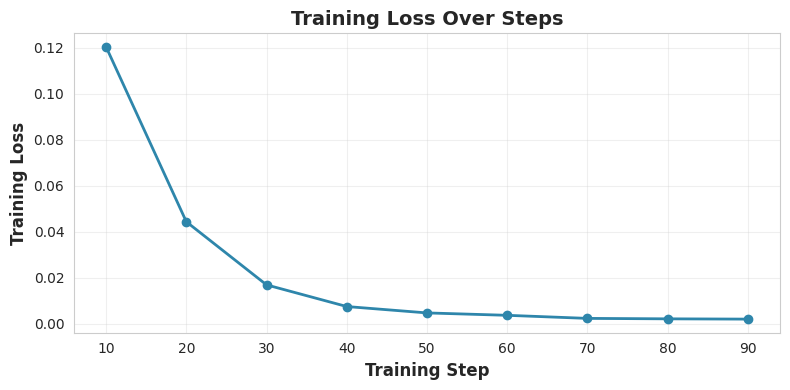

In [11]:
plt.figure(figsize=(8, 4))
plt.plot(steps, loss, marker='o', linewidth=2, markersize=6, color='#2E86AB')
plt.xlabel('Training Step', fontsize=12, fontweight='bold')
plt.ylabel('Training Loss', fontsize=12, fontweight='bold')
plt.title('Training Loss Over Steps', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

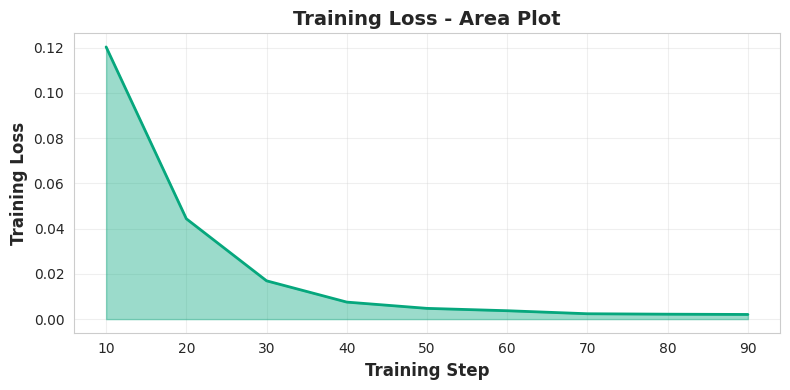

In [12]:
plt.figure(figsize=(8, 4))
plt.fill_between(steps, loss, alpha=0.4, color='#06A77D')
plt.plot(steps, loss, linewidth=2, color='#06A77D')
plt.xlabel('Training Step', fontsize=12, fontweight='bold')
plt.ylabel('Training Loss', fontsize=12, fontweight='bold')
plt.title('Training Loss - Area Plot', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

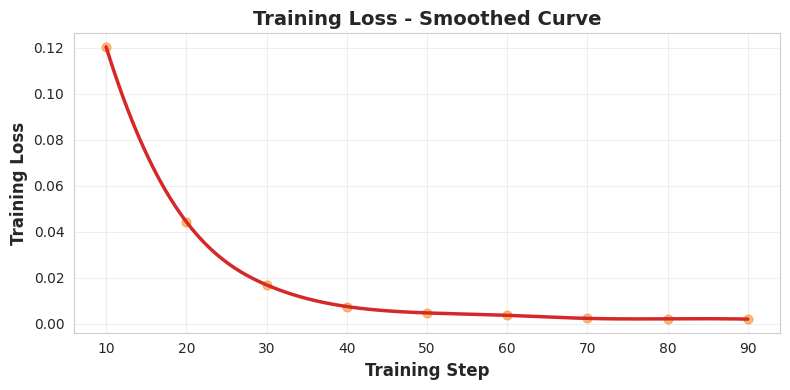

In [13]:
plt.figure(figsize=(8, 4))
x_smooth = np.linspace(min(steps), max(steps), 300)
spl = make_interp_spline(steps, loss, k=3)
y_smooth = spl(x_smooth)
plt.plot(x_smooth, y_smooth, linewidth=2.5, color='#D62828')
plt.scatter(steps, loss, s=40, alpha=0.5, color='#F77F00')
plt.xlabel('Training Step', fontsize=12, fontweight='bold')
plt.ylabel('Training Loss', fontsize=12, fontweight='bold')
plt.title('Training Loss - Smoothed Curve', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

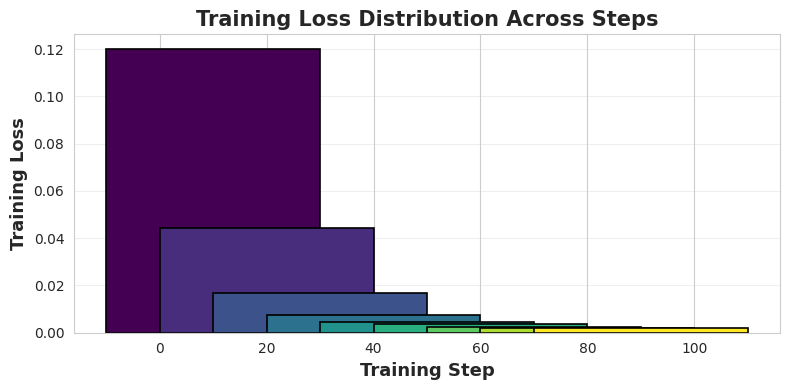

In [14]:
plt.figure(figsize=(8, 4))
colors = plt.cm.viridis(np.linspace(0, 1, len(steps)))
bars = plt.bar(steps, loss, width=40, color=colors, edgecolor='black', linewidth=1.2)
plt.xlabel('Training Step', fontsize=13, fontweight='bold')
plt.ylabel('Training Loss', fontsize=13, fontweight='bold')
plt.title('Training Loss Distribution Across Steps', fontsize=15, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Saving Adapters To Drive

In [15]:
from google.colab import drive
drive.mount('/content/drive')
!cp /content/lfm2_resume_parser_finetuned.zip /content/drive/MyDrive/


Mounted at /content/drive
